# Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
print("✅ Library siap")

d:\Tugas Besar ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Library siap


# Load Dataset

In [2]:
train_df = pd.read_csv('../data/aug_train.csv')
test_df  = pd.read_csv('../data/aug_test.csv')

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head()

Train shape: (19158, 14)
Test shape : (2129, 13)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


# EDA

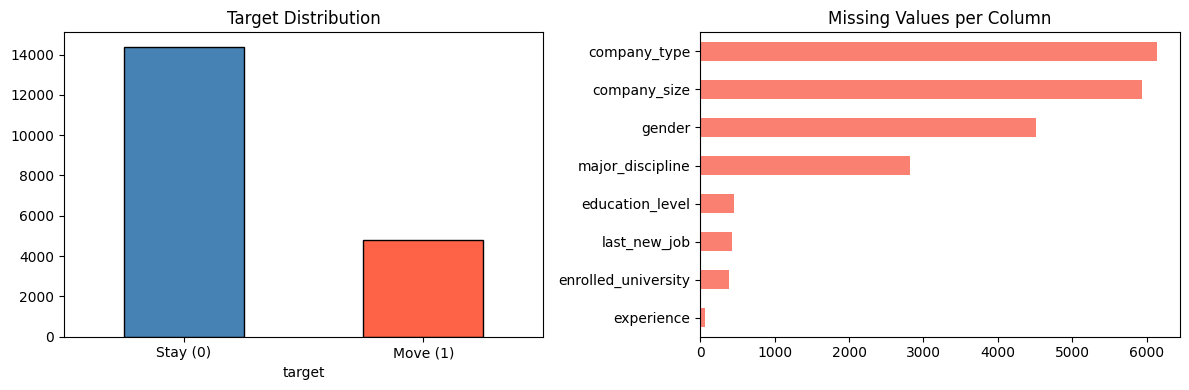


Target ratio:
 target
0.0    0.751
1.0    0.249
Name: proportion, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['target'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black'
)
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(['Stay (0)', 'Move (1)'], rotation=0)

missing = train_df.isnull().sum()
missing[missing > 0].sort_values().plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Missing Values per Column')

plt.tight_layout()
plt.show()

print("\nTarget ratio:\n", train_df['target'].value_counts(normalize=True).round(3))

# Analisis Missing Values

In [5]:
missing_cols = ['gender', 'enrolled_university', 'education_level',
                'major_discipline', 'experience', 'company_size',
                'company_type', 'last_new_job']

for col in missing_cols:
    missing_mask = train_df[col].isnull()
    if missing_mask.sum() > 0:
        target_mean_missing     = train_df[missing_mask]['target'].mean()
        target_mean_not_missing = train_df[~missing_mask]['target'].mean()
        print(f"{col:20s} | missing→target={target_mean_missing:.3f} | "
              f"not missing→target={target_mean_not_missing:.3f} | "
              f"diff={abs(target_mean_missing - target_mean_not_missing):.3f}")

gender               | missing→target=0.308 | not missing→target=0.231 | diff=0.077
enrolled_university  | missing→target=0.319 | not missing→target=0.248 | diff=0.071
education_level      | missing→target=0.226 | not missing→target=0.250 | diff=0.024
major_discipline     | missing→target=0.195 | not missing→target=0.259 | diff=0.064
experience           | missing→target=0.354 | not missing→target=0.249 | diff=0.105
company_size         | missing→target=0.406 | not missing→target=0.179 | diff=0.227
company_type         | missing→target=0.388 | not missing→target=0.184 | diff=0.204
last_new_job         | missing→target=0.364 | not missing→target=0.247 | diff=0.117


# Preprocessing dan Fitur Engineering

In [7]:
def preprocess_v3_fe(df, is_train=True):
    df = df.copy()
    df.drop(columns=['enrollee_id', 'city'], inplace=True)

    if is_train:
        y = df.pop('target').astype(int)

    # 1. Missing Indicator Flags
    flag_cols = ['gender', 'company_size', 'company_type',
                 'major_discipline', 'last_new_job', 'enrolled_university']
    for col in flag_cols:
        df[f'{col}_missing'] = df[col].isnull().astype(int)

    # 2. Imputasi
    mode_cols = ['gender', 'enrolled_university', 'education_level',
                 'major_discipline', 'experience', 'last_new_job']
    for col in mode_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    df['company_size'] = df['company_size'].fillna('Unknown')
    df['company_type'] = df['company_type'].fillna('Unknown')

    # 3. Feature Engineering
    df['job_hopper'] = (
        (df['last_new_job'].isin(['1', 'never'])) &
        (df['experience'].isin(['<1','1','2','3','4','5']))
    ).astype(int)

    df['high_value_candidate'] = (
        (df['experience'].isin(['10','11','12','13','14','15','>20'])) &
        (df['education_level'].isin(['Masters', 'Phd']))
    ).astype(int)

    df['is_fresher'] = (
        (df['experience'].isin(['<1', '1', '2'])) &
        (df['enrolled_university'] != 'no_enrollment')
    ).astype(int)

    df['mismatch_candidate'] = (
        (df['relevent_experience'] == 'No relevent experience') &
        (df['company_size'].isin(['<10', '10/49', '50-99', 'Unknown']))
    ).astype(int)

    df['ambitious'] = (
        (df['city_development_index'] < 0.75) &
        (df['training_hours'] > 50)
    ).astype(int)

    df['career_stagnant'] = (
        (df['last_new_job'].isin(['>4', '4'])) &
        (df['experience'].isin(['10','11','12','13','14','15','>20']))
    ).astype(int)

    exp_map = {'<1': 0.5, '>20': 21}
    exp_numeric = df['experience'].replace(exp_map)
    exp_numeric = pd.to_numeric(exp_numeric, errors='coerce').fillna(1)
    df['training_per_exp'] = df['training_hours'] / (exp_numeric + 1)

    df['city_tier'] = pd.cut(
        df['city_development_index'],
        bins=[0, 0.62, 0.78, 0.90, 1.0],
        labels=[0, 1, 2, 3]
    ).astype(int)

    # 4. Ordinal Encoding
    ordinal_config = {
        'experience'     : ['<1','1','2','3','4','5','6','7','8','9','10',
                            '11','12','13','14','15','16','17','18','19','20','>20'],
        'last_new_job'   : ['never','1','2','3','4','>4'],
        'company_size'   : ['<10','10/49','50-99','100-500','500-999',
                            '1000-4999','5000-9999','10000+','Unknown'],
        'education_level': ['Primary School','High School','Graduate','Masters','Phd'],
    }
    for col, order in ordinal_config.items():
        enc = OrdinalEncoder(
            categories=[order],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        )
        df[col] = enc.fit_transform(df[[col]])

    # 5. Nominal Encoding
    nominal_cols = ['gender', 'relevent_experience', 'enrolled_university',
                    'major_discipline', 'company_type']
    for col in nominal_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

    if is_train:
        return df, y
    return df


X, y = preprocess_v3_fe(train_df, is_train=True)
X_test_final = preprocess_v3_fe(test_df, is_train=False)

print(f"✅ Total fitur: {X.shape[1]} kolom")
print("Kolom:", X.columns.tolist())

✅ Total fitur: 25 kolom
Kolom: ['city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'gender_missing', 'company_size_missing', 'company_type_missing', 'major_discipline_missing', 'last_new_job_missing', 'enrolled_university_missing', 'job_hopper', 'high_value_candidate', 'is_fresher', 'mismatch_candidate', 'ambitious', 'career_stagnant', 'training_per_exp', 'city_tier']


# Training dan SMOTE

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Sebelum SMOTE:", y_train.value_counts().to_dict())
print("Sesudah SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

Sebelum SMOTE: {0: 11504, 1: 3822}
Sesudah SMOTE: {0: 11504, 1: 11504}


# Baseline Model

In [9]:
base_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
base_rf.fit(X_train_res, y_train_res)

y_pred_base  = base_rf.predict(X_val)
y_proba_base = base_rf.predict_proba(X_val)[:, 1]

print("=== BASELINE RANDOM FOREST ===")
print(classification_report(y_val, y_pred_base))
print(f"ROC-AUC : {roc_auc_score(y_val, y_proba_base):.4f}")

=== BASELINE RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      2877
           1       0.56      0.57      0.56       955

    accuracy                           0.78      3832
   macro avg       0.71      0.71      0.71      3832
weighted avg       0.78      0.78      0.78      3832

ROC-AUC : 0.7889


# Feature Importance

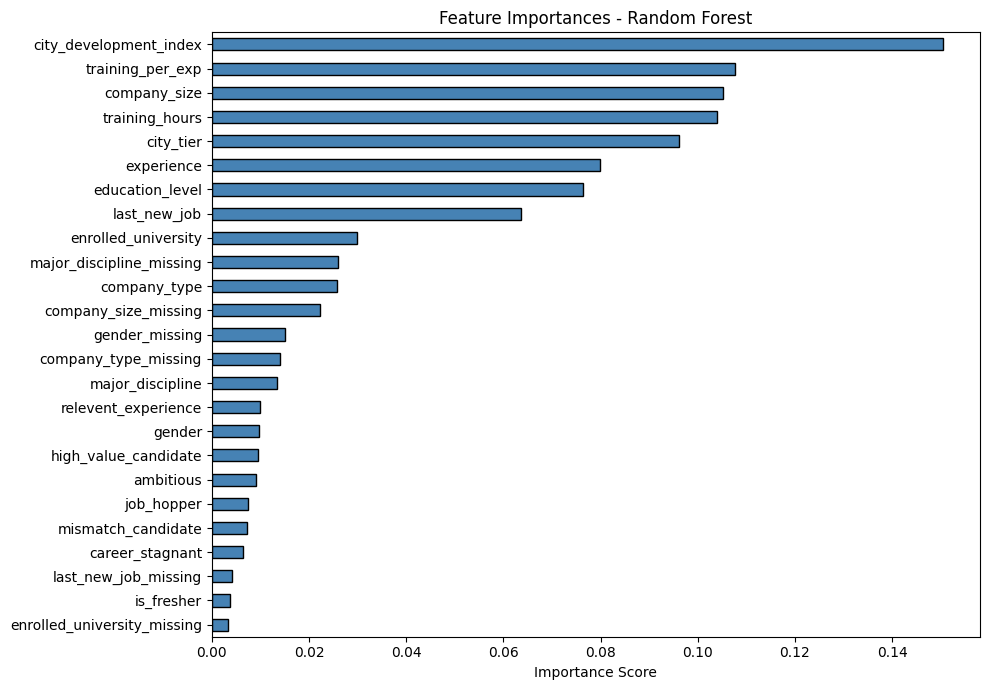


Top 10 fitur:
city_development_index      0.150548
training_per_exp            0.107586
company_size                0.105165
training_hours              0.103898
city_tier                   0.096032
experience                  0.079964
education_level             0.076291
last_new_job                0.063628
enrolled_university         0.029915
major_discipline_missing    0.026034
dtype: float64


In [10]:
importances = pd.Series(base_rf.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances_sorted.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(f"\nTop 10 fitur:")
print(importances.sort_values(ascending=False).head(10))

# Hyperparameter Tuning

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 700),
        'max_depth'        : trial.suggest_int('max_depth', 8, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 2, 6),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight'     : trial.suggest_categorical('class_weight', ['balanced', None]),
    }
    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    score = cross_val_score(rf, X_train_res, y_train_res,
                            cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best ROC-AUC (CV): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best trial: 41. Best value: 0.914032: 100%|██████████| 50/50 [03:20<00:00,  4.00s/it]


✅ Best ROC-AUC (CV): 0.9140
Best params: {'n_estimators': 437, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}


# Train Model Final

In [12]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train_res, y_train_res)
print("✅ Model final selesai ditraining")

✅ Model final selesai ditraining


# Evaluasi Model

=== FINAL RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      2877
           1       0.55      0.69      0.61       955

    accuracy                           0.78      3832
   macro avg       0.72      0.75      0.73      3832
weighted avg       0.80      0.78      0.79      3832

ROC-AUC : 0.7986


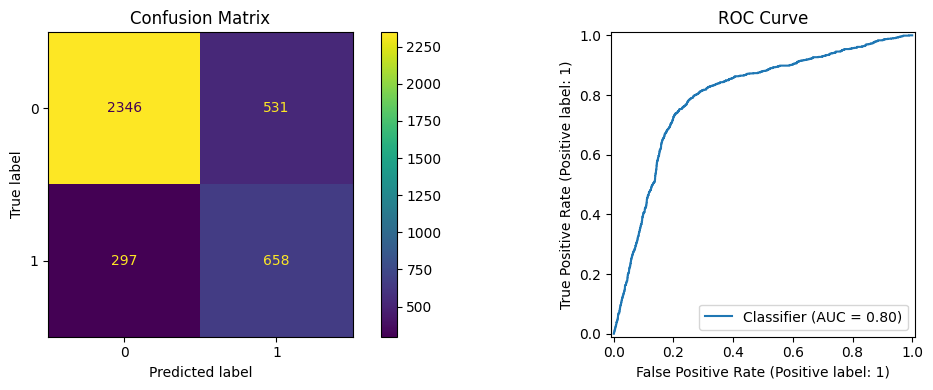


=== PERBANDINGAN ===
Baseline AUC : 0.7889
Tuned AUC    : 0.7986


In [13]:
y_pred  = best_rf.predict(X_val)
y_proba = best_rf.predict_proba(X_val)[:, 1]

print("=== FINAL RANDOM FOREST ===")
print(classification_report(y_val, y_pred))
print(f"ROC-AUC : {roc_auc_score(y_val, y_proba):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=axes[0])
axes[0].set_title('Confusion Matrix')
RocCurveDisplay.from_predictions(y_val, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.show()

print("\n=== PERBANDINGAN ===")
print(f"Baseline AUC : {roc_auc_score(y_val, y_proba_base):.4f}")
print(f"Tuned AUC    : {roc_auc_score(y_val, y_proba):.4f}")

# Simpan Model

In [14]:
os.makedirs('../models', exist_ok=True)

joblib.dump(best_rf, '../models/random_forest_model.pkl')

feature_names = X.columns.tolist()
joblib.dump(feature_names, '../models/selected_features.pkl')

with open('../models/best_params_rf.json', 'w') as f:
    json.dump(study.best_params, f, indent=2)

joblib.dump({
    'n_features'   : X.shape[1],
    'feature_names': feature_names,
    'model_version': 'FE+Tuned',
    'auc'          : round(roc_auc_score(y_val, y_proba), 4),
    'macro_f1'     : 0.73
}, '../models/model_metadata.pkl')

print("✅ Model tersimpan!")
print("Files:", os.listdir('../models'))

✅ Model tersimpan!
Files: ['best_params_rf.json', 'model_metadata.pkl', 'random_forest_model.pkl', 'selected_features.pkl']


# Sanity Cek

In [15]:
sample = X_val.iloc[:5]
pred   = best_rf.predict(sample)
proba  = best_rf.predict_proba(sample)[:, 1]

result = pd.DataFrame({
    'Actual'      : y_val.iloc[:5].values,
    'Predicted'   : pred,
    'Prob(Pindah)': proba.round(3)
})
print(result)

   Actual  Predicted  Prob(Pindah)
0       0          0         0.061
1       1          1         0.705
2       0          0         0.084
3       1          0         0.190
4       1          0         0.467
